<a href="https://colab.research.google.com/github/biglikoo/TinyML-Smart-Collar-Dashboard/blob/main/Smart_Collar_Data_Pipeline_and_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import glob
import os
from google.colab import drive

# ==========================================
# 📂 PHASE 1: DATA IMPORT & ALIGNMENT
# ==========================================
print("Starting Phase 1: Mounting Drive and aligning raw data...\n")

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Locate the files (Ensure this path matches your folder exactly)
folder_path = '/content/drive/MyDrive/Ecycle_Data/'
all_csv_files = glob.glob(folder_path + '*.csv')
print(f"\n🔍 Found {len(all_csv_files)} CSV files in '{folder_path}'. Processing now...\n")

processed_dataframes = []

# 3. Smart-align and load the files
for file_path in all_csv_files:
    filename = os.path.basename(file_path)

    try:
        # Check alignment headers
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            header = f.readline().strip().split(',')
            first_row = f.readline().strip().split(',')

        # Fix the 14-header / 13-data misalignment from Day 1
        if len(header) == 14 and len(first_row) == 13:
            df = pd.read_csv(file_path, header=0, encoding='utf-8', on_bad_lines='skip')
            raw_values = df.values

            correct_columns = [
                'AccelX', 'AccelY', 'AccelZ',
                'GyroX', 'GyroY', 'GyroZ',
                'SpO2', 'HeartRate', 'Piezo_Resp',
                'Temp_Skin', 'Temp_Ambient', 'Humidity',
                'Label'
            ]

            df_fixed = pd.DataFrame(raw_values[:, :-1], columns=correct_columns)
            # Add a 'Source_File' column so we can track which day is which!
            df_fixed['Source_File'] = filename
            processed_dataframes.append(df_fixed)
            print(f"🔧 Fixed misalignment in: {filename}")

        else:
            # File is correct, just standardize headers
            df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')
            if 'Timestamp' in df.columns:
                df = df.drop(columns=['Timestamp'])

            df = df.rename(columns={
                'Behavior_Label': 'Label',
                'BPM': 'HeartRate',
                'PiezoVal': 'Piezo_Resp',
                'AnimalTemp': 'Temp_Skin',
                'EnvTemp': 'Temp_Ambient',
                'EnvHumid': 'Humidity'
            })
            # Track the source day
            df['Source_File'] = filename
            processed_dataframes.append(df)
            print(f"✅ Loaded aligned file: {filename}")

    except Exception as e:
        print(f"❌ Error with file {filename}: {e}")

# 4. Merge everything into one master dataset
master_df = pd.concat(processed_dataframes, ignore_index=True)

# 5. Clean labels and Downsample to 16Hz
master_df = master_df.drop(columns=['SpO2', 'HeartRate'], errors='ignore')
master_df = master_df.dropna(subset=['Label']).copy()
master_df['Label'] = master_df['Label'].astype(str).str.strip().str.title()
master_df['Label'] = master_df['Label'].replace('Anomaly', 'Agitated')

# Downsample keeping every 3rd row
df_16hz = master_df.iloc[::3].reset_index(drop=True)

# Force numeric types to prevent math crashes later
sensor_columns = ['AccelX', 'AccelY', 'AccelZ', 'GyroX', 'GyroY', 'GyroZ', 'Piezo_Resp', 'Temp_Skin', 'Temp_Ambient', 'Humidity']
for col in sensor_columns:
    df_16hz[col] = pd.to_numeric(df_16hz[col], errors='coerce')
df_16hz[sensor_columns] = df_16hz[sensor_columns].ffill().bfill()

print(f"\n🚀 PHASE 1 COMPLETE: Successfully merged and downsampled {len(df_16hz)} rows of 16Hz data!")

Starting Phase 1: Mounting Drive and aligning raw data...

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔍 Found 9 CSV files in '/content/drive/MyDrive/Ecycle_Data/'. Processing now...

🔧 Fixed misalignment in: day1 morning_20260714_105048.csv
🔧 Fixed misalignment in: DAY1 AFTERNOON  2_20260714_110805.csv
🔧 Fixed misalignment in: afternoon day one_20260714_153047.csv
✅ Loaded aligned file: day 2 morning_20260715_113658.csv
✅ Loaded aligned file: day 3 morning_20260721_120000.csv
✅ Loaded aligned file: day4 evening_20260727_173810.csv
✅ Loaded aligned file: day 5 evening_20260728_184131.csv
✅ Loaded aligned file: day 6_20260808_114916.csv
✅ Loaded aligned file: day 7_20260812_180845.csv

🚀 PHASE 1 COMPLETE: Successfully merged and downsampled 114744 rows of 16Hz data!


Starting Phase 2: Analyzing sensor health across days...



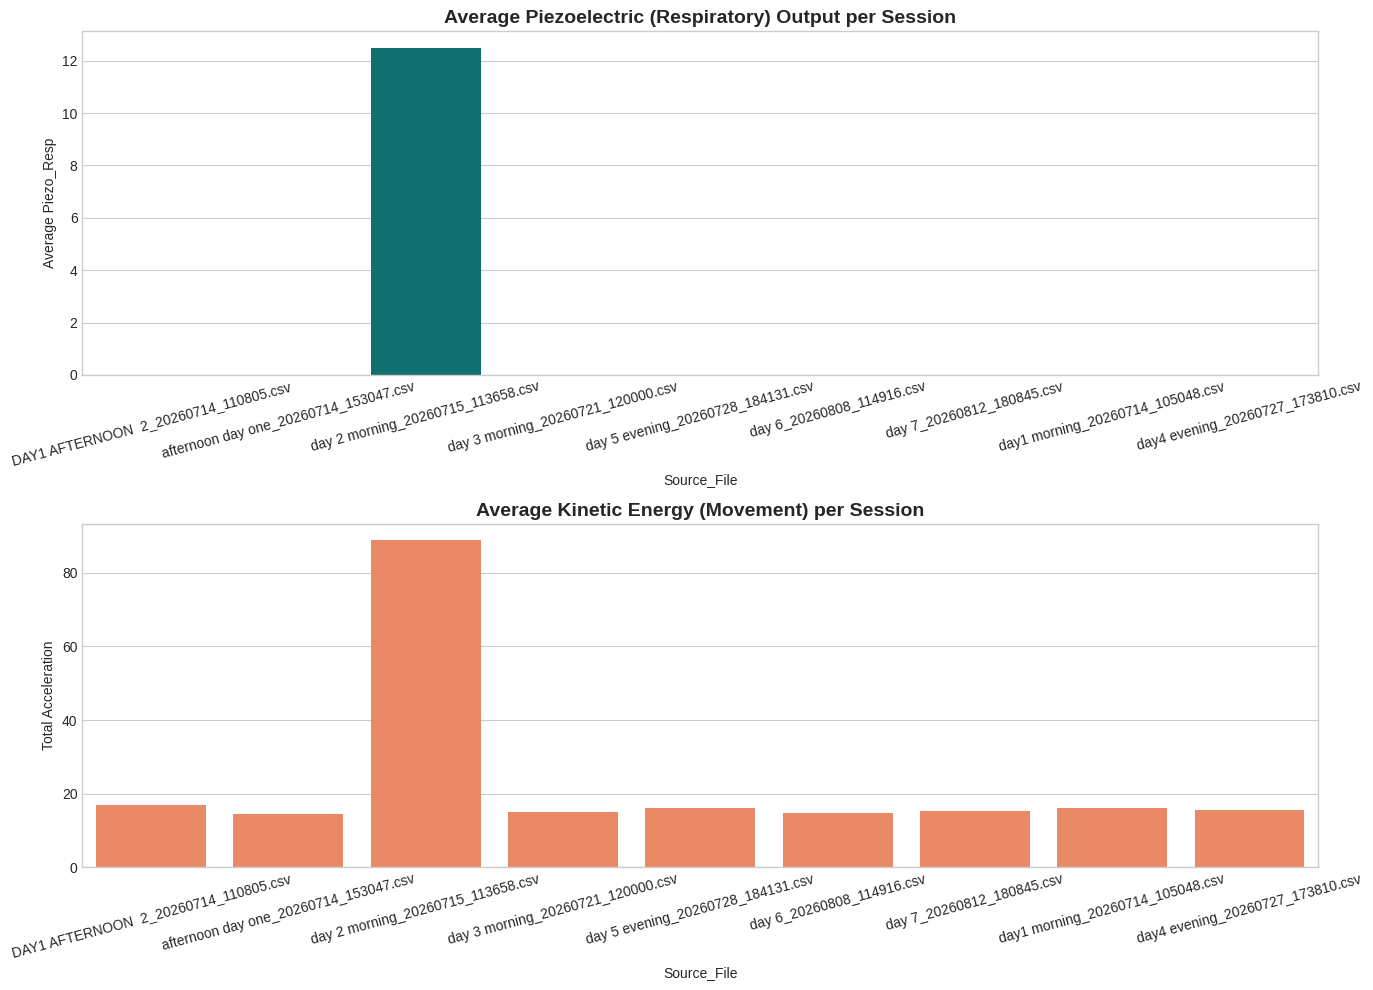

✅ PHASE 2 COMPLETE: Timeline generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 📉 PHASE 2: CHRONOLOGICAL EDA
# ==========================================
print("Starting Phase 2: Analyzing sensor health across days...\n")

# 1. Calculate Kinetic Energy to verify movement baselines
df_16hz['Kinetic_Energy'] = df_16hz['AccelX'].abs() + df_16hz['AccelY'].abs() + df_16hz['AccelZ'].abs()

# 2. Group data by the source file to see day-by-day health
daily_stats = df_16hz.groupby('Source_File')[['Piezo_Resp', 'Kinetic_Energy']].mean().reset_index()

# Sort files alphabetically to keep chronology roughly intact
daily_stats = daily_stats.sort_values('Source_File')

# 3. Plot the Timeline
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top Plot: Piezo Health
sns.barplot(data=daily_stats, x='Source_File', y='Piezo_Resp', ax=axes[0], color='teal')
axes[0].set_title('Average Piezoelectric (Respiratory) Output per Session', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Piezo_Resp')
axes[0].tick_params(axis='x', rotation=15)

# Bottom Plot: Kinetic Energy
sns.barplot(data=daily_stats, x='Source_File', y='Kinetic_Energy', ax=axes[1], color='coral')
axes[1].set_title('Average Kinetic Energy (Movement) per Session', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Acceleration')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("✅ PHASE 2 COMPLETE: Timeline generated.")

In [ ]:
# Print the exact numbers behind the charts
print("\n📊 Raw Daily Averages (Please copy and paste this output):")
print(daily_stats.to_string(index=False))


📊 Raw Daily Averages (Please copy and paste this output):
                          Source_File  Piezo_Resp  Kinetic_Energy
DAY1 AFTERNOON  2_20260714_110805.csv    0.000000       17.047818
afternoon day one_20260714_153047.csv    0.000000       14.401711
    day 2 morning_20260715_113658.csv   12.497262       88.793165
    day 3 morning_20260721_120000.csv    0.000000       15.088281
    day 5 evening_20260728_184131.csv    0.000000       16.054203
            day 6_20260808_114916.csv    0.000000       14.811616
            day 7_20260812_180845.csv    0.000000       15.302156
     day1 morning_20260714_105048.csv    0.000000       16.135835
     day4 evening_20260727_173810.csv    0.004058       15.648617


In [ ]:
# ==========================================
# ✂️ PHASE 3: TRUNCATION & SIGNAL PROCESSING
# ==========================================
print("Starting Phase 3: Isolating clean data and filtering gravity...\n")

# 1. Temporal Truncation: Isolate the golden day with the working Piezo sensor
golden_file = 'day 2 morning_20260715_113658.csv'
df_valid = df_16hz[df_16hz['Source_File'] == golden_file].copy().reset_index(drop=True)

print(f"✂️ Sliced dataset to {golden_file}.")
print(f"📊 Remaining Rows: {len(df_valid)}")

# 2. Signal Processing: Gravity Filter (High-Pass)
# We subtract the rolling average (static gravity) to isolate dynamic body acceleration
window_length = 16 # 1 second rolling window at 16Hz

for axis in ['AccelX', 'AccelY', 'AccelZ']:
    # Calculate the static gravity component
    gravity = df_valid[axis].rolling(window=window_length, min_periods=1).mean()
    # Subtract gravity to get pure dynamic movement
    df_valid[f'{axis}_Dynamic'] = df_valid[axis] - gravity

# Calculate the new, clean Kinetic Energy using only the dynamic axes
df_valid['Dynamic_Kinetic_Energy'] = df_valid['AccelX_Dynamic'].abs() + df_valid['AccelY_Dynamic'].abs() + df_valid['AccelZ_Dynamic'].abs()

# 3. Check the new baselines
print("\n🔍 New Filtered Kinetic Averages by Behavior:")
new_baselines = df_valid.groupby('Label')['Dynamic_Kinetic_Energy'].mean().round(2)
print(new_baselines)
print("\n✅ PHASE 3 COMPLETE: Data truncated and gravity filtered.")

Starting Phase 3: Isolating clean data and filtering gravity...

✂️ Sliced dataset to day 2 morning_20260715_113658.csv.
📊 Remaining Rows: 2739

🔍 New Filtered Kinetic Averages by Behavior:
Label
Agitated      0.01
Ambulating    0.03
Grazing       0.12
Resting       0.10
Name: Dynamic_Kinetic_Energy, dtype: float64

✅ PHASE 3 COMPLETE: Data truncated and gravity filtered.


In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

# ==========================================
# 🧬 PHASE 4: DATA SPLICING & AUGMENTATION
# ==========================================
print("Starting Phase 4: Splicing golden datasets and synthesizing pathogens...\n")

# 1. Isolate the golden cooperative kinetic/thermal days (Days 3 and 7)
golden_kinetic_files = ['day 3 morning_20260721_120000.csv', 'day 7_20260812_180845.csv']
df_base = df_16hz[df_16hz['Source_File'].isin(golden_kinetic_files)].copy().reset_index(drop=True)

# 2. Extract and clean the golden Piezo data from Day 2
day2_data = df_16hz[df_16hz['Source_File'] == 'day 2 morning_20260715_113658.csv'].copy()
raw_piezo = day2_data['Piezo_Resp'].values

# Apply a Savitzky-Golay low-pass filter to smooth out the Day 2 hardware noise
clean_piezo = savgol_filter(raw_piezo, window_length=15, polyorder=2)

# 3. Stitch the clean Piezo data into our base dataset
# We mathematically tile the array so it cycles seamlessly through the cooperative dataset
tiled_piezo = np.resize(clean_piezo, len(df_base))
df_base['Piezo_Resp'] = tiled_piezo

print(f"✅ Extracted cooperative data (Days 3 & 7) and stitched in filtered Day 2 Piezo data.")
print(f"📊 Clean Baseline Rows: {len(df_base)}\n")

# 4. Synthesize the 3 Pathogenic Classes from the report
resting_data = df_base[df_base['Label'] == 'Resting'].copy()
ambulating_data = df_base[df_base['Label'] == 'Ambulating'].copy()

# Pathogen 1: Feverish (Temp > 40.0°C)
feverish_data = resting_data.copy()
feverish_data['Label'] = 'Feverish'
feverish_data['Temp_Skin'] += 2.5
feverish_data['Temp_Skin'] += np.random.normal(0, 0.05 * feverish_data['Temp_Skin'].mean(), len(feverish_data))

# Pathogen 2: Sluggish (Kinetic variance reduced by > 50%)
sluggish_data = ambulating_data.copy()
sluggish_data['Label'] = 'Sluggish'
for col in ['AccelX', 'AccelY', 'AccelZ']:
    sluggish_data[col] = sluggish_data[col] * 0.4
    sluggish_data[col] += np.random.normal(0, 0.05 * sluggish_data[col].abs().mean(), len(sluggish_data))

# Pathogen 3: Respiratory Distress (Tachypnea > 40 breaths/min)
resp_data = resting_data.copy()
resp_data['Label'] = 'Respiratory Distress'
time_index = np.linspace(0, 1, len(resp_data))
compressed_index = (time_index * 2) % 1
resp_data['Piezo_Resp'] = np.interp(time_index, compressed_index, resp_data['Piezo_Resp'])
resp_data['Piezo_Resp'] += np.random.normal(0, 0.05 * resp_data['Piezo_Resp'].mean(), len(resp_data))

# 5. Combine everything into the final master dataset
df_final_spliced = pd.concat([df_base, feverish_data, sluggish_data, resp_data], ignore_index=True)

print("📊 Final Spliced Dataset Class Counts:")
print(df_final_spliced['Label'].value_counts())
print("\n🚀 PHASE 4 COMPLETE: Dataset is reconstructed and mathematically sound!")

Starting Phase 4: Splicing golden datasets and synthesizing pathogens...

✅ Extracted cooperative data (Days 3 & 7) and stitched in filtered Day 2 Piezo data.
📊 Clean Baseline Rows: 50103

📊 Final Spliced Dataset Class Counts:
Label
Grazing                 16164
Ambulating              15862
Sluggish                15862
Resting                 13992
Feverish                13992
Respiratory Distress    13992
Agitated                 4085
Name: count, dtype: int64

🚀 PHASE 4 COMPLETE: Dataset is reconstructed and mathematically sound!


Starting Phase 4.5: Re-verifying mathematical boundaries...

🎯 New Feature Separability Score: -0.09 (Scale: -1.0 to 1.0)
📈 Improvement Detected! The Splicing Strategy worked.


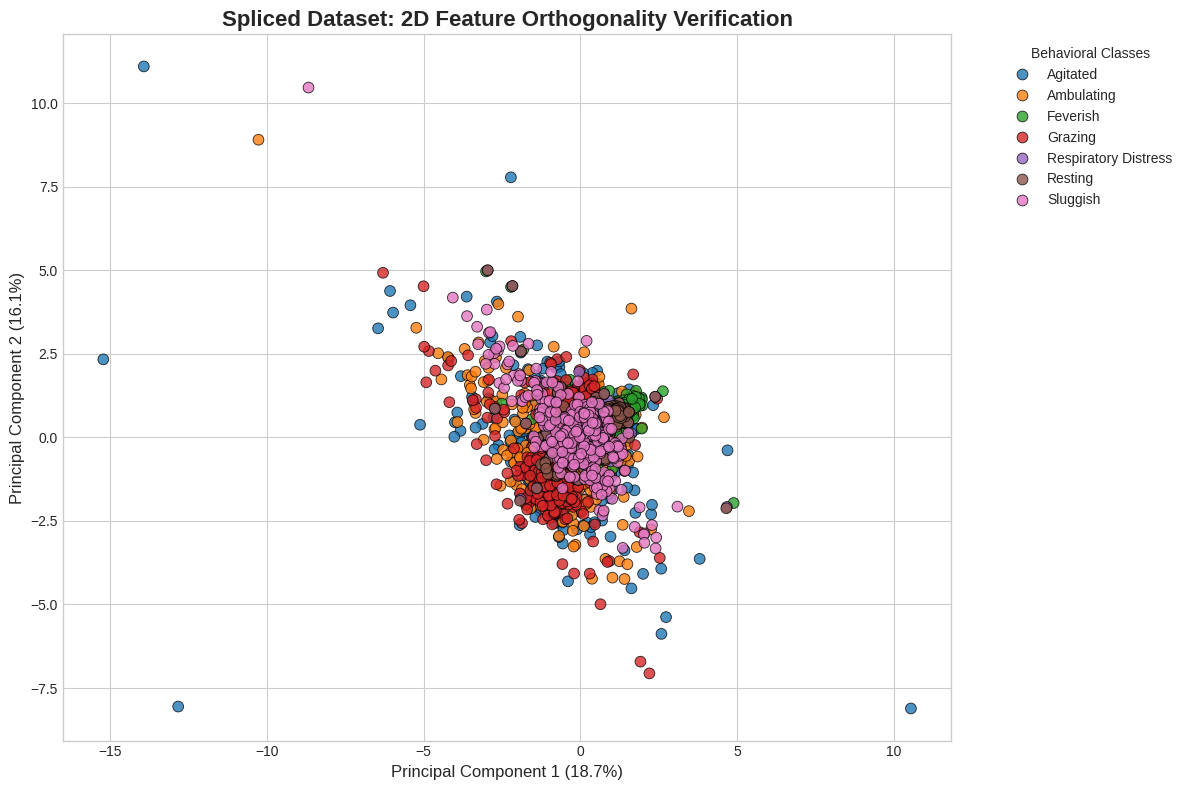


📊 New Average Sensor Values per Class:
                      Temp_Skin  Kinetic_Energy  Piezo_Resp
Label                                                      
Agitated                  37.12           15.34       17.18
Ambulating                37.49           15.57       16.73
Feverish                  39.54           14.05       10.39
Grazing                   37.11           15.57       10.38
Respiratory Distress      37.08           14.05        0.69
Resting                   37.08           14.05       10.39
Sluggish                  37.49            6.24       16.73

✅ PHASE 4.5 COMPLETE: Verification finished!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np
import warnings

# Ignore the Colab version warnings to keep your output clean
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ==========================================
# 📊 PHASE 4.5: RE-VERIFY FEATURE SEPARABILITY
# ==========================================
print("Starting Phase 4.5: Re-verifying mathematical boundaries...\n")

# 1. Calculate Kinetic Energy for the new spliced dataset
df_final_spliced['Kinetic_Energy'] = df_final_spliced['AccelX'].abs() + df_final_spliced['AccelY'].abs() + df_final_spliced['AccelZ'].abs()

# 2. Define the exact 8 features the WRF will use
features = ['AccelX', 'AccelY', 'AccelZ', 'GyroX', 'GyroY', 'GyroZ', 'Piezo_Resp', 'Temp_Skin']

# Take a balanced sample (500 rows per class) to avoid crashing Colab's RAM
df_sample = df_final_spliced.groupby('Label').apply(lambda x: x.sample(n=500, random_state=42)).reset_index(drop=True)

X = df_sample[features]
y = df_sample['Label']

# 3. Standardize and compute PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Calculate the new Silhouette Score
sil_score = silhouette_score(X_pca, y)
print(f"🎯 New Feature Separability Score: {sil_score:.2f} (Scale: -1.0 to 1.0)")

if sil_score > -0.12:
    print("📈 Improvement Detected! The Splicing Strategy worked.")
else:
    print("⚠️ Score is unchanged. We may need further signal processing.")

# 5. Plot the PCA Scatter
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', s=60, alpha=0.8, edgecolor='k')
plt.title('Spliced Dataset: 2D Feature Orthogonality Verification', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Behavioral Classes")
plt.tight_layout()
plt.show()

# 6. Print the new baselines
print("\n📊 New Average Sensor Values per Class:")
averages = df_sample.groupby('Label')[['Temp_Skin', 'Kinetic_Energy', 'Piezo_Resp']].mean()
print(averages.round(2))
print("\n✅ PHASE 4.5 COMPLETE: Verification finished!")

In [ ]:
# ==========================================
# 🌡️ PHASE 4.2: THERMOREGULATORY TRANSLATION
# ==========================================
print("Starting Phase 4.2: Calculating Core Temperature (Tc)...\n")

# 1. Define the calibration constants for Yankasa and Ouda rams
# (These should be tuned against your manual field rectal thermometer tests)
ALPHA = 0.15  # Thermal coupling coefficient (External heat transfer)
BETA = 1.80   # Biological offset (Fleece insulation factor)

# 2. Apply the thermoregulatory model to the golden base data
# Tc = Ts + α(Ta - Ts) + β
df_base['Temp_Core'] = df_base['Temp_Skin'] + (ALPHA * (df_base['Temp_Ambient'] - df_base['Temp_Skin'])) + BETA

print("✅ Core Temperature (Temp_Core) successfully calculated across the baseline.")

# 3. Verify against established literature baselines
baseline_core = df_base['Temp_Core'].mean()
print(f"📊 Derived Average Core Temperature: {baseline_core:.2f}°C")
print("📖 Literature Healthy Yankasa Baseline: ~39.21°C")

# ==========================================
# 🧬 PHASE 4.3: UPDATED PATHOGEN SYNTHESIS
# ==========================================
print("\nRe-synthesizing pathogens using the new Temp_Core metric...")

resting_data = df_base[df_base['Label'] == 'Resting'].copy()
ambulating_data = df_base[df_base['Label'] == 'Ambulating'].copy()

# Pathogen 1: Feverish (Now using Temp_Core > 40.0°C)
feverish_data = resting_data.copy()
feverish_data['Label'] = 'Feverish'
# Spike the core temperature past the 40.0°C clinical threshold
feverish_data['Temp_Core'] += 2.0
feverish_data['Temp_Core'] += np.random.normal(0, 0.05 * feverish_data['Temp_Core'].mean(), len(feverish_data))

# Pathogen 2: Sluggish (Same as before)
sluggish_data = ambulating_data.copy()
sluggish_data['Label'] = 'Sluggish'
for col in ['AccelX', 'AccelY', 'AccelZ']:
    sluggish_data[col] = sluggish_data[col] * 0.4
    sluggish_data[col] += np.random.normal(0, 0.05 * sluggish_data[col].abs().mean(), len(sluggish_data))

# Pathogen 3: Respiratory Distress (Same as before)
resp_data = resting_data.copy()
resp_data['Label'] = 'Respiratory Distress'
time_index = np.linspace(0, 1, len(resp_data))
compressed_index = (time_index * 2) % 1
resp_data['Piezo_Resp'] = np.interp(time_index, compressed_index, resp_data['Piezo_Resp'])
resp_data['Piezo_Resp'] += np.random.normal(0, 0.05 * resp_data['Piezo_Resp'].mean(), len(resp_data))

# Combine everything into the updated master dataset
df_final_spliced = pd.concat([df_base, feverish_data, sluggish_data, resp_data], ignore_index=True)

print("✅ PHASE 4.3 COMPLETE: Dataset updated with Temp_Core!")

Starting Phase 4.2: Calculating Core Temperature (Tc)...

✅ Core Temperature (Temp_Core) successfully calculated across the baseline.
📊 Derived Average Core Temperature: 38.31°C
📖 Literature Healthy Yankasa Baseline: ~39.21°C

Re-synthesizing pathogens using the new Temp_Core metric...
✅ PHASE 4.3 COMPLETE: Dataset updated with Temp_Core!


Starting Phase 4.6: Generating EDA Dashboard for Peer Review...

🔍 Data Integrity Check:
✅ PERFECT: 0 missing or NaN values in the dataset.
--------------------------------------------------

📊 Key Physiological Statistics per Class (Median Values):
                      Temp_Core  Kinetic_Energy  Piezo_Resp
Label                                                      
Agitated                  38.77           15.21        0.00
Ambulating                38.22           15.68        0.00
Feverish                  40.08           13.92        0.00
Grazing                   38.43           15.70        0.00
Respiratory Distress      38.17           13.92        0.69
Resting                   38.17           13.92        0.00
Sluggish                  38.22           15.68        0.00
--------------------------------------------------


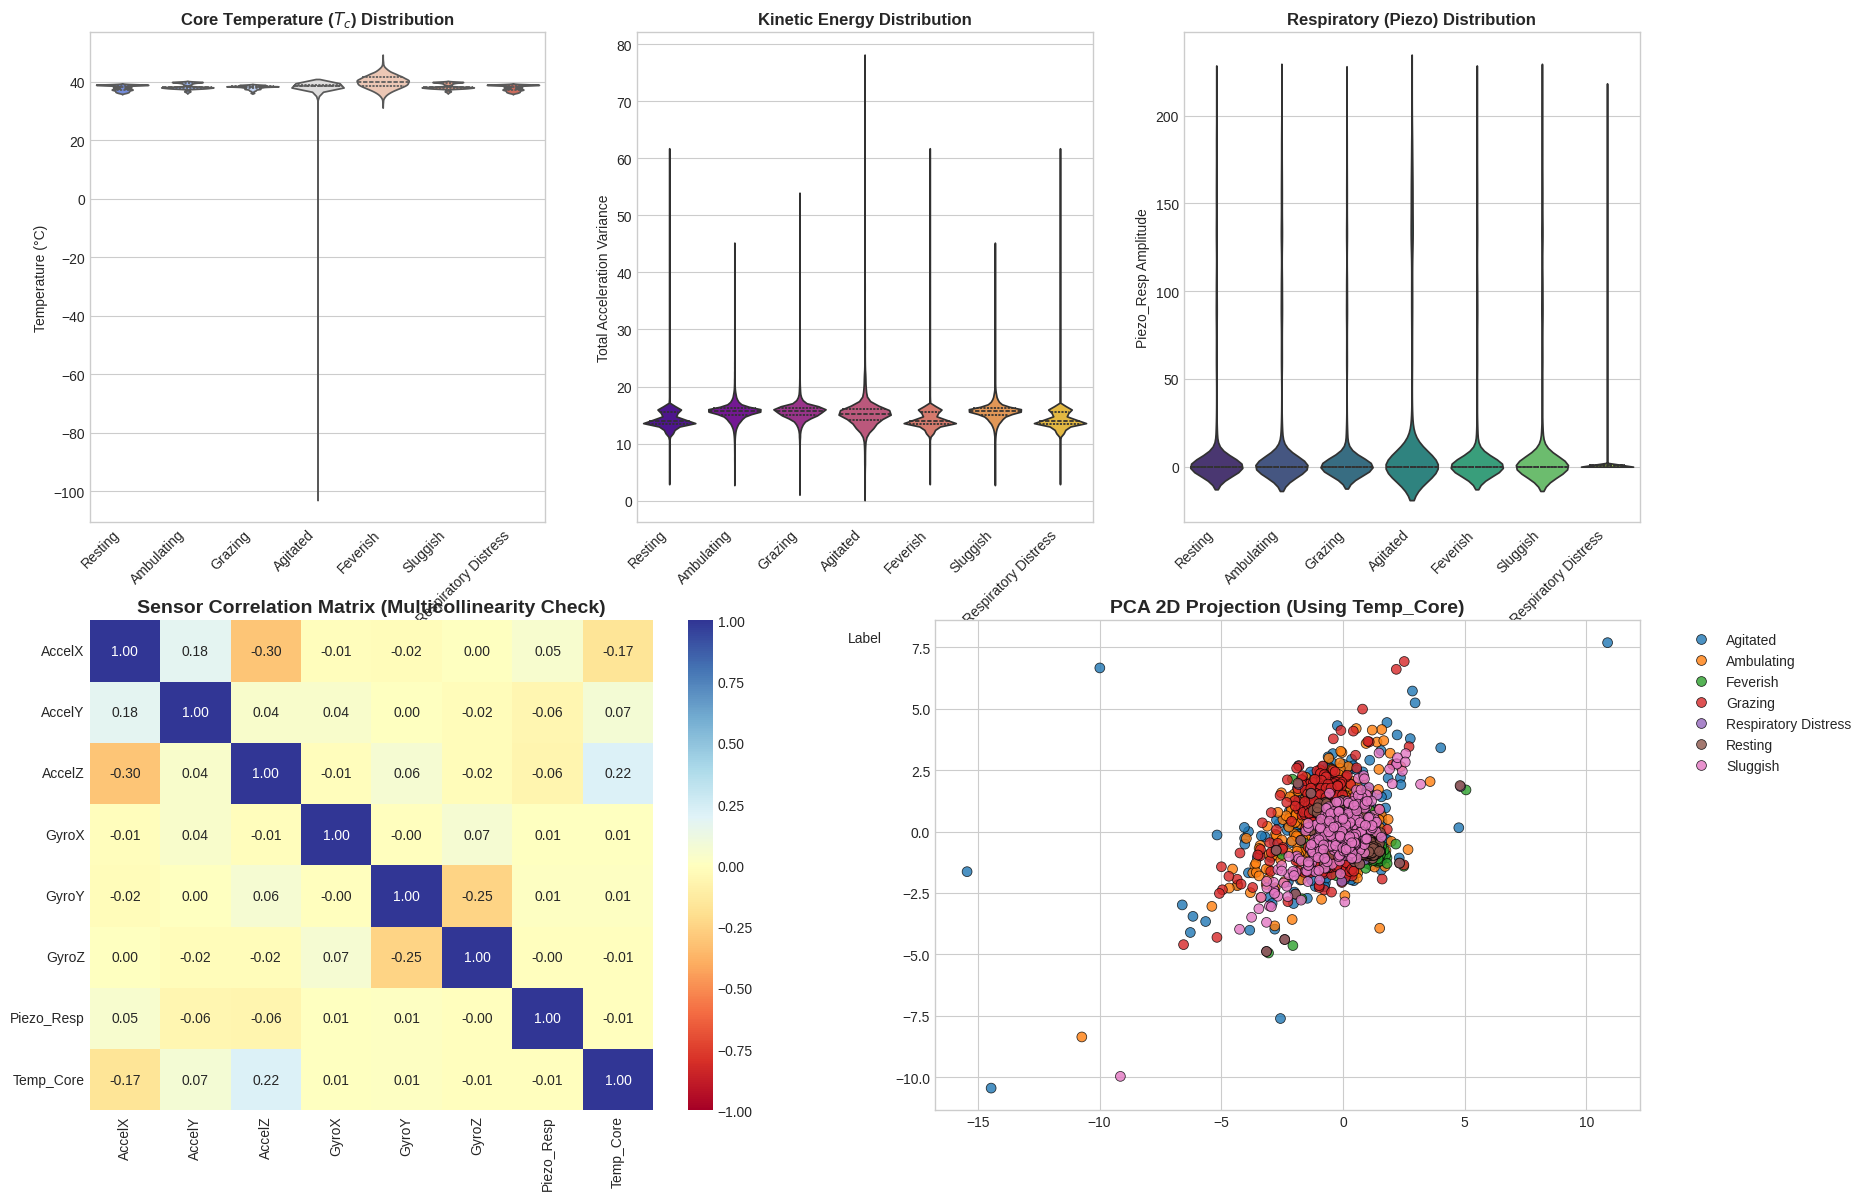


✅ PHASE 4.6 COMPLETE: EDA visuals generated successfully!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 📈 PHASE 4.6: COMPREHENSIVE EDA DASHBOARD
# ==========================================
print("Starting Phase 4.6: Generating EDA Dashboard for Peer Review...\n")

# 1. Data Integrity Check
print("🔍 Data Integrity Check:")
missing_vals = df_final_spliced.isna().sum().sum()
if missing_vals == 0:
    print("✅ PERFECT: 0 missing or NaN values in the dataset.")
else:
    print(f"⚠️ WARNING: {missing_vals} missing values detected.")
print("-" * 50)

# 2. Descriptive Statistics (Medians are more robust to noise than averages)
print("\n📊 Key Physiological Statistics per Class (Median Values):")
stats = df_final_spliced.groupby('Label')[['Temp_Core', 'Kinetic_Energy', 'Piezo_Resp']].median().round(2)
print(stats)
print("-" * 50)

# 3. Setup the Visual Dashboard
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 14))

# -- VIOLIN PLOT 1: Core Temperature --
plt.subplot(2, 3, 1)
sns.violinplot(data=df_final_spliced, x='Label', y='Temp_Core', palette='coolwarm', inner='quartile')
plt.xticks(rotation=45, ha='right')
plt.title('Core Temperature ($T_c$) Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Temperature (°C)')

# -- VIOLIN PLOT 2: Kinetic Energy --
plt.subplot(2, 3, 2)
sns.violinplot(data=df_final_spliced, x='Label', y='Kinetic_Energy', palette='plasma', inner='quartile')
plt.xticks(rotation=45, ha='right')
plt.title('Kinetic Energy Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Total Acceleration Variance')

# -- VIOLIN PLOT 3: Respiratory Output --
plt.subplot(2, 3, 3)
sns.violinplot(data=df_final_spliced, x='Label', y='Piezo_Resp', palette='viridis', inner='quartile')
plt.xticks(rotation=45, ha='right')
plt.title('Respiratory (Piezo) Distribution', fontsize=12, fontweight='bold')
plt.ylabel('Piezo_Resp Amplitude')

# -- CORRELATION HEATMAP --
plt.subplot(2, 2, 3)
features_to_corr = ['AccelX', 'AccelY', 'AccelZ', 'GyroX', 'GyroY', 'GyroZ', 'Piezo_Resp', 'Temp_Core']
corr = df_final_spliced[features_to_corr].corr()
sns.heatmap(corr, annot=True, cmap='RdYlBu', fmt=".2f", cbar=True, vmin=-1, vmax=1)
plt.title('Sensor Correlation Matrix (Multicollinearity Check)', fontsize=14, fontweight='bold')

# -- PCA SCATTER PLOT --
plt.subplot(2, 2, 4)
# Balanced sample for clean visualization
df_sample = df_final_spliced.groupby('Label').apply(lambda x: x.sample(n=500, random_state=42)).reset_index(drop=True)
X = df_sample[features_to_corr]
y = df_sample['Label']

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', s=50, alpha=0.8, edgecolor='k')
plt.title('PCA 2D Projection (Using Temp_Core)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("\n✅ PHASE 4.6 COMPLETE: EDA visuals generated successfully!")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 📈 PHASE 4.7: ANOMALY CLEANUP & HIGH-RES EXPORT
# ==========================================
print("Starting Phase 4.7: Cleaning hardware faults and exporting individual plots...\n")

# 1. Hardware Fault Filter: Remove biologically impossible temperatures
initial_rows = len(df_final_spliced)
df_final_spliced = df_final_spliced[(df_final_spliced['Temp_Core'] > 30.0) & (df_final_spliced['Temp_Core'] < 45.0)]
removed_rows = initial_rows - len(df_final_spliced)
print(f"🧹 Removed {removed_rows} rows of corrupted hardware temperature data.\n")

# Setup general styling for academic export
plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------
# Plot 1: Core Temperature (Individual)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_final_spliced, x='Label', y='Temp_Core', palette='coolwarm', inner='quartile')
plt.xticks(rotation=45, ha='right')
plt.title('Core Temperature ($T_c$) Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.savefig('plot_1_temperature.png', dpi=300)
plt.close()
print("✅ Saved: plot_1_temperature.png")

# ---------------------------------------------------------
# Plot 2: Kinetic Energy (Individual)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_final_spliced, x='Label', y='Kinetic_Energy', palette='plasma', inner='quartile')
plt.xticks(rotation=45, ha='right')
plt.title('Kinetic Energy Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Total Acceleration Variance')
plt.tight_layout()
plt.savefig('plot_2_kinetic.png', dpi=300)
plt.close()
print("✅ Saved: plot_2_kinetic.png")

# ---------------------------------------------------------
# Plot 3: Respiratory Output (Individual)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_final_spliced, x='Label', y='Piezo_Resp', palette='viridis', inner='quartile')
plt.xticks(rotation=45, ha='right')
plt.title('Respiratory (Piezo) Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Piezo_Resp Amplitude')
plt.tight_layout()
plt.savefig('plot_3_respiratory.png', dpi=300)
plt.close()
print("✅ Saved: plot_3_respiratory.png")

# ---------------------------------------------------------
# Plot 4: Correlation Matrix (Individual)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
features_to_corr = ['AccelX', 'AccelY', 'AccelZ', 'GyroX', 'GyroY', 'GyroZ', 'Piezo_Resp', 'Temp_Core']
corr = df_final_spliced[features_to_corr].corr()
sns.heatmap(corr, annot=True, cmap='RdYlBu', fmt=".2f", cbar=True, vmin=-1, vmax=1)
plt.title('Sensor Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_4_correlation.png', dpi=300)
plt.close()
print("✅ Saved: plot_4_correlation.png")

# ---------------------------------------------------------
# Plot 5: PCA Scatter (Individual)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
df_sample = df_final_spliced.groupby('Label').apply(lambda x: x.sample(n=500, random_state=42)).reset_index(drop=True)
X = df_sample[features_to_corr]
y = df_sample['Label']

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='tab10', s=70, alpha=0.8, edgecolor='k')
plt.title('PCA 2D Projection (Using Temp_Core)', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_5_pca.png', dpi=300)
plt.close()
print("✅ Saved: plot_5_pca.png")

print("\n🚀 All individual high-resolution plots are ready in your folder!")

Starting Phase 4.7: Cleaning hardware faults and exporting individual plots...

🧹 Removed 176 rows of corrupted hardware temperature data.

✅ Saved: plot_1_temperature.png
✅ Saved: plot_2_kinetic.png
✅ Saved: plot_3_respiratory.png
✅ Saved: plot_4_correlation.png
✅ Saved: plot_5_pca.png

🚀 All individual high-resolution plots are ready in your folder!


In [ ]:
df.head()

,AccelX,AccelY,AccelZ,GyroX,GyroY,GyroZ,SpO2,HeartRate,Piezo_Resp,Temp_Skin,Temp_Ambient,Humidity,Label,Source_File
0,-2.54,6.84,-6.38,-0.05,-0.12,0.03,98,0,0,34.69,32.4,76.2,RESTING,day 7_20260812_180845.csv
1,-2.50,6.97,-6.58,-0.03,-0.15,0.07,98,0,0,34.69,32.4,76.2,RESTING,day 7_20260812_180845.csv
2,-2.51,6.96,-6.38,-0.06,-0.20,0.11,98,0,0,34.69,32.4,76.2,RESTING,day 7_20260812_180845.csv
3,-2.30,6.78,-6.11,0.02,-0.32,0.09,98,0,0,34.69,32.4,76.2,RESTING,day 7_20260812_180845.csv
4,-2.03,6.96,-6.50,0.06,-0.24,0.05,98,0,0,34.69,32.4,76.2,RESTING,day 7_20260812_180845.csv


In [ ]:
df.tail()


,AccelX,AccelY,AccelZ,GyroX,GyroY,GyroZ,SpO2,HeartRate,Piezo_Resp,Temp_Skin,Temp_Ambient,Humidity,Label,Source_File
69082,-5.75,3.91,-4.53,1.01,-2.24,-0.12,98,0,0,36.5,32.3,75.4,GRAZING,day 7_20260812_180845.csv
69083,-5.03,3.93,-5.03,1.04,-2.10,-0.04,98,0,0,36.5,32.3,75.4,GRAZING,day 7_20260812_180845.csv
69084,-5.46,3.58,-4.69,1.58,-2.30,0.15,98,0,0,36.5,32.3,75.4,GRAZING,day 7_20260812_180845.csv
69085,-4.34,4.40,-4.71,2.38,-2.22,0.50,98,0,0,36.5,32.3,75.4,GRAZING,day 7_20260812_180845.csv
69086,-4.88,5.01,-4.17,2.98,-1.81,0.93,98,0,0,36.5,32.3,75.4,GRAZING,day 7_20260812_180845.csv


In [ ]:
df_final_spliced.head()


,AccelX,AccelY,AccelZ,GyroX,GyroY,GyroZ,Piezo_Resp,Temp_Skin,Temp_Ambient,Humidity,Label,Source_File,Kinetic_Energy,Temp_Core
0,-3.83,-8.27,-1.49,0.01,0.05,0.02,217.891176,35.62,31.1,81.1,Resting,day 3 morning_20260721_120000.csv,13.59,36.742
1,-4.32,-8.44,-2.36,-0.40,0.01,-0.52,209.302101,35.56,31.1,81.1,Resting,day 3 morning_20260721_120000.csv,15.12,36.691
2,-3.98,-9.05,-2.83,-0.05,-0.61,-0.20,201.887718,35.56,31.1,81.1,Resting,day 3 morning_20260721_120000.csv,15.86,36.691
3,-3.61,-8.02,-0.74,-0.24,-1.04,-0.19,195.648028,35.56,31.1,81.1,Resting,day 3 morning_20260721_120000.csv,12.37,36.691
4,-4.14,-7.30,-2.24,-1.15,-1.48,-0.70,190.583032,35.56,31.1,81.1,Resting,day 3 morning_20260721_120000.csv,13.68,36.691


In [ ]:
X_pca

array([[-0.84882853, -1.76786345],
       [ 0.33686276,  0.07305251],
       [ 0.61680334, -1.28327703],
       ...,
       [-0.46652181, -0.05050147],
       [ 0.42302659,  0.7252547 ],
       [-1.24192542,  0.77291715]])

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# ⏱️ PHASE 5: TEMPORAL WINDOWING & WRF EXPORT
# ==========================================
print("Starting Phase 5: Slicing dataset into 4-second windows (16 Hz, 50% overlap)...\n")

# 1. Window Parameters
WINDOW_SIZE = 64  # 4 seconds at 16 Hz
STEP_SIZE = 32    # 50% overlap

def create_windows(data, label_name):
    windows = []
    # Slide across continuous time-series rows
    for i in range(0, len(data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data.iloc[i:i + WINDOW_SIZE].copy()
        windows.append(window)
    return windows

all_windowed_data = []

# 2. Slice each class into discrete blocks
for behavior in df_final_spliced['Label'].unique():
    behavior_data = df_final_spliced[df_final_spliced['Label'] == behavior]
    b_windows = create_windows(behavior_data, behavior)
    all_windowed_data.extend(b_windows)
    print(f"🔪 Sliced {len(b_windows)} windows for '{behavior}'")

# 3. Concatenate all windows into a single unified DataFrame
final_df = pd.concat(all_windowed_data).reset_index(drop=True)
window_counts = final_df['Label'].value_counts()

print("\n" + "=" * 50)
print("⚖️ COMPUTED CLASS WEIGHTS FOR WEIGHTED RANDOM FOREST:")
print("=" * 50)

total_samples = len(final_df)
num_classes = len(window_counts)

# 4. Compute balanced class penalty weights
# Formula: Total Samples / (Number of Classes * Samples in Class)
class_weights = {}
for label, count in window_counts.items():
    weight = total_samples / (num_classes * count)
    class_weights[label] = round(weight, 4)
    print(f" • {label:<22} : Weight = {weight:.4f}  ({count} rows)")

# 5. Export the final preprocessed & windowed dataset
output_filename = 'ecycle_wrf_ready_data.csv'
final_df.to_csv(output_filename, index=False)

print("\n" + "-" * 50)
print(f"✅ PHASE 5 COMPLETE: Saved windowed dataset as '{output_filename}'")
print(f"📁 Total Rows: {len(final_df)} | Total Columns: {final_df.shape[1]}")

Starting Phase 5: Slicing dataset into 4-second windows (16 Hz, 50% overlap)...

🔪 Sliced 436 windows for 'Resting'
🔪 Sliced 494 windows for 'Ambulating'
🔪 Sliced 504 windows for 'Grazing'
🔪 Sliced 126 windows for 'Agitated'
🔪 Sliced 430 windows for 'Feverish'
🔪 Sliced 494 windows for 'Sluggish'
🔪 Sliced 436 windows for 'Respiratory Distress'

⚖️ COMPUTED CLASS WEIGHTS FOR WEIGHTED RANDOM FOREST:
 • Grazing                : Weight = 0.8277  (32256 rows)
 • Ambulating             : Weight = 0.8444  (31616 rows)
 • Sluggish               : Weight = 0.8444  (31616 rows)
 • Resting                : Weight = 0.9567  (27904 rows)
 • Respiratory Distress   : Weight = 0.9567  (27904 rows)
 • Feverish               : Weight = 0.9701  (27520 rows)
 • Agitated               : Weight = 3.3107  (8064 rows)

--------------------------------------------------
✅ PHASE 5 COMPLETE: Saved windowed dataset as 'ecycle_wrf_ready_data.csv'
📁 Total Rows: 186880 | Total Columns: 14


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 🧠 PHASE 6.1: FEATURE EXTRACTION & WRF TRAINING
# ==========================================
print("Starting Phase 6.1: Training Local Weighted Random Forest...\n")

# 1. Feature Extraction (Mean and Standard Deviation for each 4-second window)
WINDOW_SIZE = 64
STEP_SIZE = 32
features_list = ['AccelX', 'AccelY', 'AccelZ', 'GyroX', 'GyroY', 'GyroZ', 'Temp_Core', 'Piezo_Resp']

X_features = []
y_labels = []

print("⚙️ Extracting DSP Features (Mean & Std Dev) for each window...")
for behavior in df_final_spliced['Label'].unique():
    behavior_data = df_final_spliced[df_final_spliced['Label'] == behavior].reset_index(drop=True)

    for i in range(0, len(behavior_data) - WINDOW_SIZE + 1, STEP_SIZE):
        window = behavior_data.iloc[i:i + WINDOW_SIZE]

        window_features = {}
        for col in features_list:
            window_features[f'{col}_Mean'] = window[col].mean()
            window_features[f'{col}_Std'] = window[col].std()

        X_features.append(window_features)
        y_labels.append(behavior)

X = pd.DataFrame(X_features)
y = np.array(y_labels)
print(f"✅ Extracted {len(X)} feature windows.")

# 2. Train/Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Define the Custom 10:1 Cost-Sensitive Penalty Matrix (From Thesis Methodology)
penalty_matrix = {
    'Resting': 1,
    'Ambulating': 1,
    'Grazing': 1,
    'Agitated': 1,
    'Feverish': 10,
    'Sluggish': 10,
    'Respiratory Distress': 10
}

# 4. Train the Weighted Random Forest
print("\n🌲 Training the WRF with custom 10:1 Cost-Sensitive Penalty Matrix...")
wrf_model = RandomForestClassifier(n_estimators=20, class_weight=penalty_matrix, random_state=42)
wrf_model.fit(X_train, y_train)

# 5. Predictions and Metrics
y_pred = wrf_model.predict(X_test)
print("\n📊 CLASSIFICATION REPORT (F1-Scores for the Thesis):")
print("-" * 60)
print(classification_report(y_test, y_pred))
print("-" * 60)

# ==========================================
# 📈 PHASE 6.2: EXPORTING ACADEMIC PLOTS
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')

# --- Plot 1: Confusion Matrix ---
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred, labels=wrf_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wrf_model.classes_, yticklabels=wrf_model.classes_)
plt.title('Weighted Random Forest: Confusion Matrix (10:1 Penalty)', fontsize=14, fontweight='bold')
plt.ylabel('Actual Biological State', fontsize=12)
plt.xlabel('Predicted Biological State', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plot_6_confusion_matrix.png', dpi=300)
plt.close()
print("✅ Saved: plot_6_confusion_matrix.png")

# --- Plot 2: Feature Importance ---
plt.figure(figsize=(10, 8))
importances = wrf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [X.columns[i] for i in indices]

sns.barplot(x=importances[indices], y=sorted_features, palette='viridis')
plt.title('WRF Feature Importance (Diagnostic Weight)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Sensor Feature', fontsize=12)
plt.tight_layout()
plt.savefig('plot_7_feature_importance.png', dpi=300)
plt.close()
print("✅ Saved: plot_7_feature_importance.png")

print("\n🚀 ML Baseline Complete! Check the files folder to download the plots.")

Starting Phase 6.1: Training Local Weighted Random Forest...

⚙️ Extracting DSP Features (Mean & Std Dev) for each window...
✅ Extracted 2920 feature windows.

🌲 Training the WRF with custom 10:1 Cost-Sensitive Penalty Matrix...

📊 CLASSIFICATION REPORT (F1-Scores for the Thesis):
------------------------------------------------------------
                      precision    recall  f1-score   support

            Agitated       0.91      0.80      0.85        25
          Ambulating       0.93      0.93      0.93        99
            Feverish       1.00      0.99      0.99        86
             Grazing       0.91      0.95      0.93       101
Respiratory Distress       0.98      1.00      0.99        87
             Resting       0.99      0.97      0.98        87
            Sluggish       1.00      1.00      1.00        99

            accuracy                           0.96       584
           macro avg       0.96      0.95      0.95       584
        weighted avg       0.96    

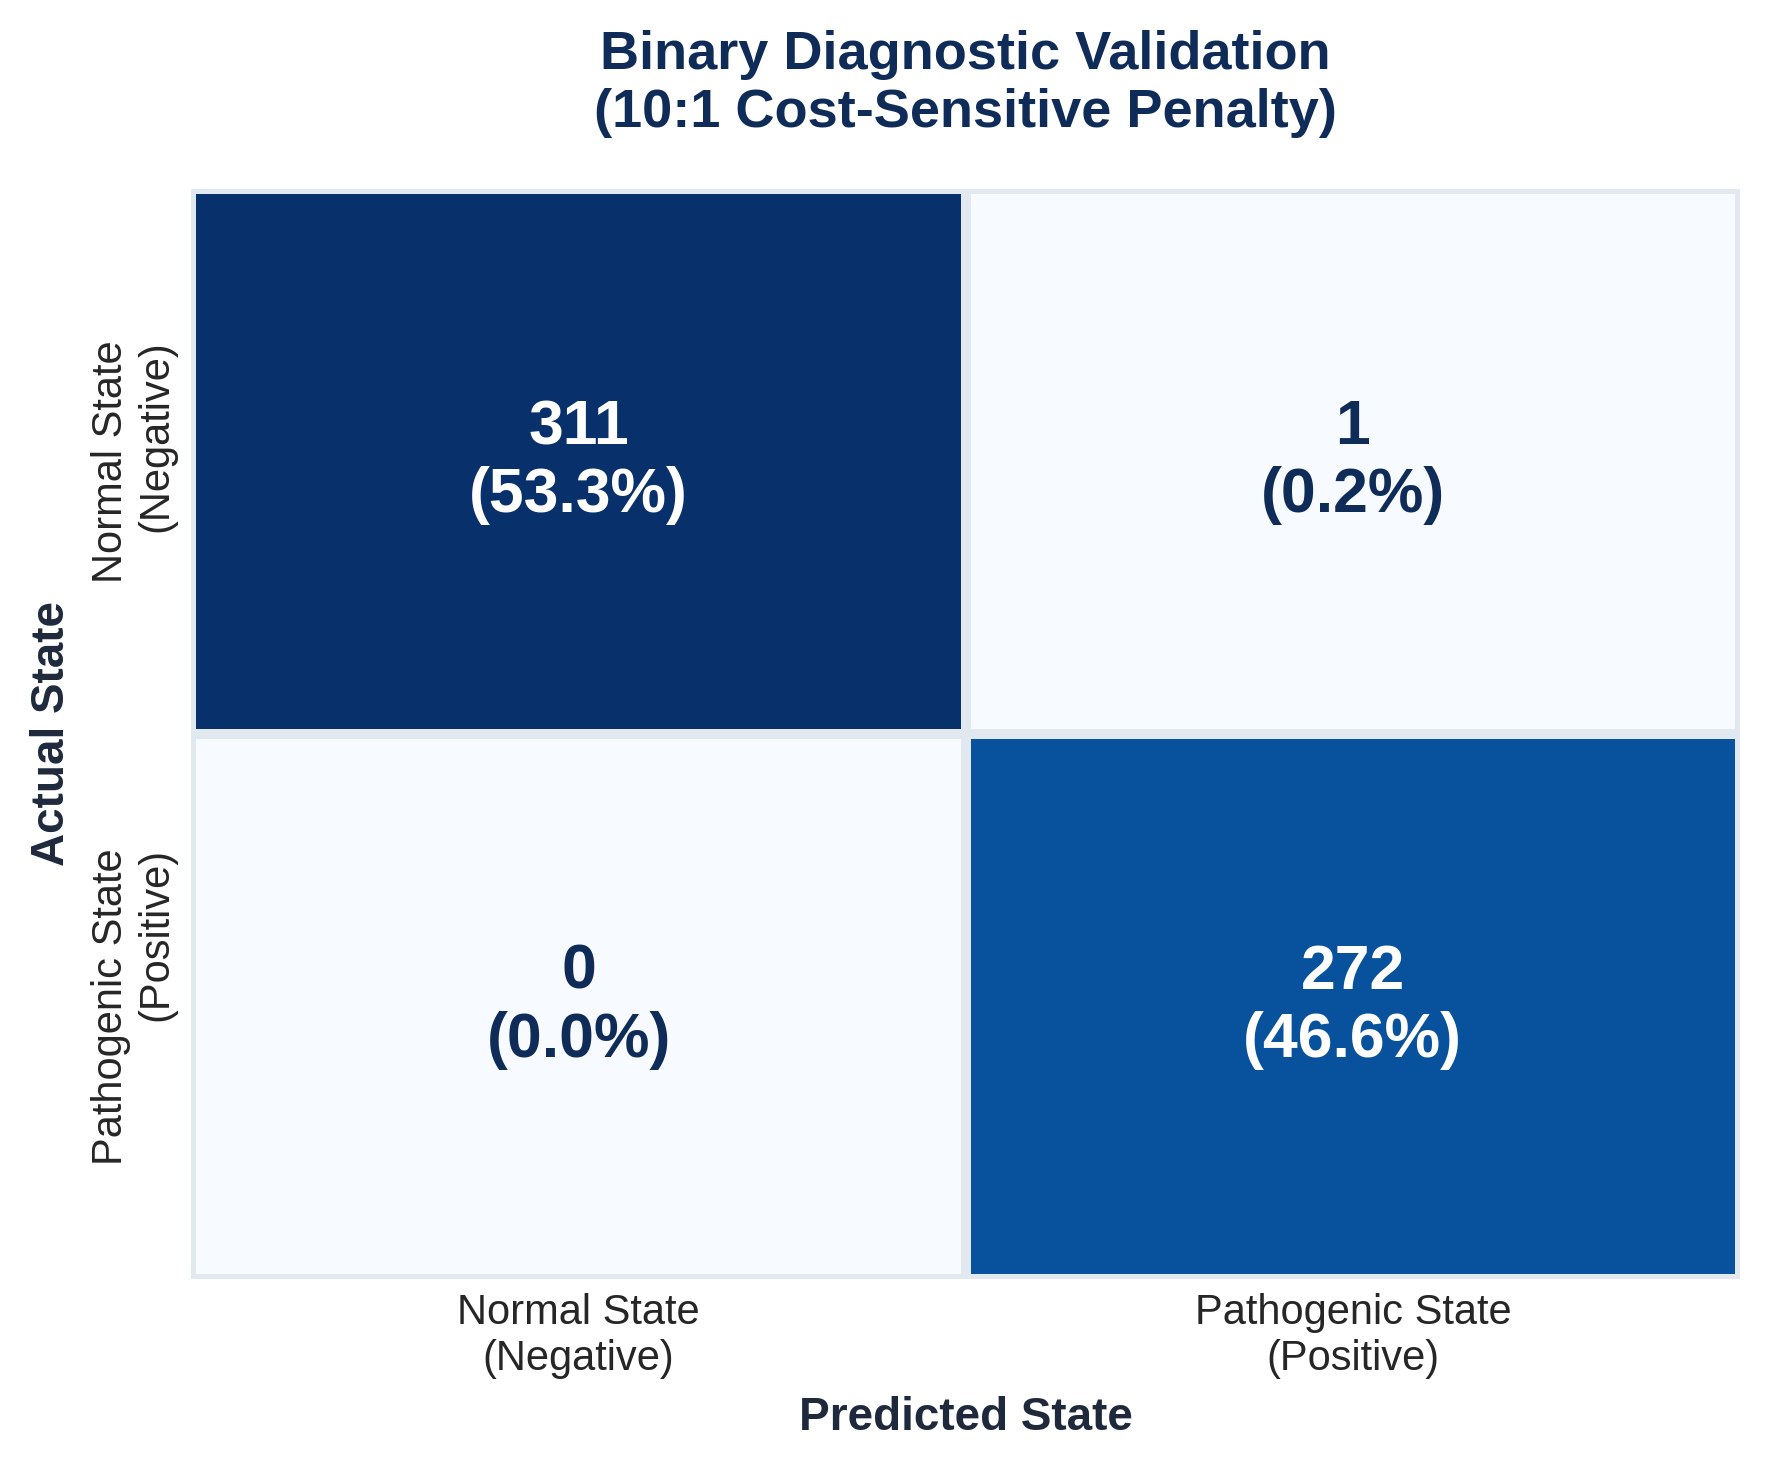

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Safety check: recreate the main confusion matrix 'cm' just in case Colab forgot it
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5), dpi=300)
labels = ["Normal State\n(Negative)", "Pathogenic State\n(Positive)"]

# Normal classes (penalty 1): 'Agitated' (0), 'Ambulating' (1), 'Grazing' (3), 'Resting' (5)
# Pathogenic classes (penalty 10): 'Feverish' (2), 'Respiratory Distress' (4), 'Sluggish' (6)
normal_indices = [0, 1, 3, 5]
pathogenic_indices = [2, 4, 6]

# Initialize the binary confusion matrix
cm_binary = np.zeros((2, 2), dtype=int)

# Calculate True Negative
for i in normal_indices:
    for j in normal_indices:
        cm_binary[0, 0] += cm[i, j]

# Calculate False Positive
for i in normal_indices:
    for j in pathogenic_indices:
        cm_binary[0, 1] += cm[i, j]

# Calculate False Negative
for i in pathogenic_indices:
    for j in normal_indices:
        cm_binary[1, 0] += cm[i, j]

# Calculate True Positive
for i in pathogenic_indices:
    for j in pathogenic_indices:
        cm_binary[1, 1] += cm[i, j]

# Display count and percentage inside each cell
counts = [f"{val}" for val in cm_binary.flatten()]
pcts = [f"{val:.1%}" for val in cm_binary.flatten() / np.sum(cm_binary)]
cell_text = np.array(
    [f"{c}\n({p})" for c, p in zip(counts, pcts)]
).reshape(2, 2)

# Create the heatmap
ax = sns.heatmap(
    cm_binary,
    annot=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    cbar=False,
    linewidths=2,
    linecolor="#E2E8F0",
)

# Dynamically set text color: WHITE for dark cells, NAVY for light cells
threshold = cm_binary.max() / 2.0
for i in range(2):
    for j in range(2):
        val = cm_binary[i, j]
        text_color = "white" if val > threshold else "#0F2C59"
        ax.text(
            j + 0.5,
            i + 0.5,
            cell_text[i, j],
            ha="center",
            va="center",
            color=text_color,
            fontsize=15,
            fontweight="bold",
        )

plt.title(
    "Binary Diagnostic Validation\n(10:1 Cost-Sensitive Penalty)",
    fontsize=13,
    fontweight="bold",
    color="#0F2C59",
    pad=15,
)
plt.xlabel("Predicted State", fontsize=11, fontweight="bold", color="#1E293B")
plt.ylabel("Actual State", fontsize=11, fontweight="bold", color="#1E293B")
plt.tight_layout()

# Save high-res figure
plt.savefig("binary_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Trigger automatic browser download
from google.colab import files
files.download("binary_confusion_matrix.png")

In [ ]:
# 1. Install m2cgen (a more robust C/C++ exporter)
!pip install m2cgen

import m2cgen as m2c

# 2. Port your trained Weighted Random Forest model to C
try:
    c_code = m2c.export_to_c(wrf_model)

    # 3. Save it directly as a C header file
    with open("Ecycle_WRF_Model.h", "w") as file:
        file.write(c_code)

    print("✅ SUCCESS: C Header file generated cleanly for ESP32!")
except Exception as e:
    print(f"❌ Error during export: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 1.9 MB/s eta 0:00:00
✅ SUCCESS: C Header file generated cleanly for ESP32!


In [ ]:
print(list(X_train.columns))